/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.7591] [D acc: 0.7266] [G loss: 0.2144]


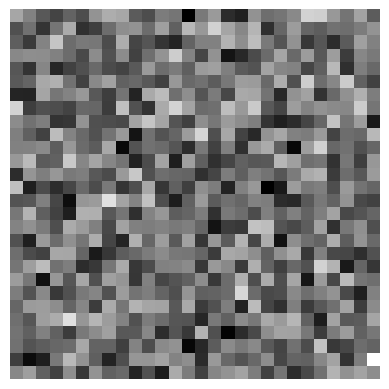

500 [D loss: 4.4821] [D acc: 0.4893] [G loss: 0.0021]


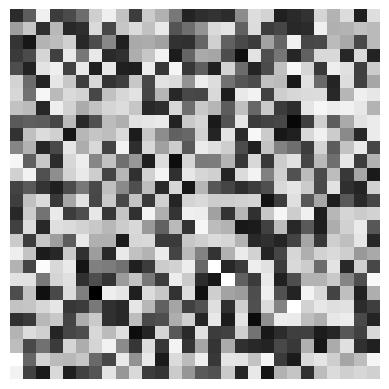

1000 [D loss: 4.9309] [D acc: 0.4895] [G loss: 0.0010]


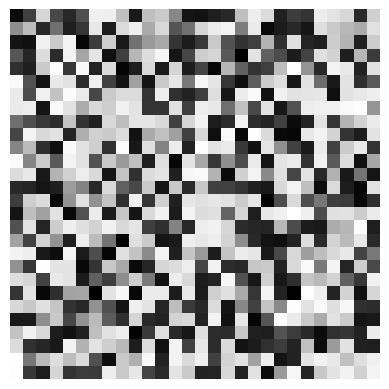

1500 [D loss: 5.2062] [D acc: 0.4894] [G loss: 0.0007]


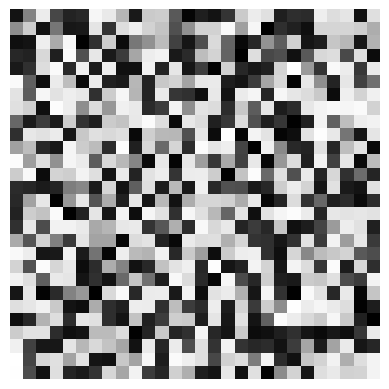

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Load MNIST dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
X_train = X_train / 255.0  # normalize to [0,1]
# keep shape (28,28), do not flatten

# 2. Build Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_dim=100),
        layers.Dense(28*28, activation="sigmoid"),
        layers.Reshape((28,28))   # output image
    ])
    return model

# 3. Build Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28)),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# 4. Create models
generator = build_generator()
discriminator = build_discriminator()

# 5. Combine them (GAN = Generator + Discriminator)
z = layers.Input(shape=(100,))
img = generator(z)
discriminator.trainable = False   # freeze discriminator in GAN
valid = discriminator(img)

gan = tf.keras.Model(z, valid)
gan.compile(optimizer="adam", loss="binary_crossentropy")

# 6. Training loop
epochs = 2000
batch_size = 128

for epoch in range(epochs):
    # ---- Train Discriminator ----
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]  # shape (batch,28,28)

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    # ---- Train Generator ----
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    # ---- Print & visualize ----
    if epoch % 500 == 0:
        print(f"{epoch} [D loss: {0.5 * (d_loss_real[0] + d_loss_fake[0]):.4f}] "
              f"[D acc: {0.5 * (d_loss_real[1] + d_loss_fake[1]):.4f}] "
              f"[G loss: {g_loss:.4f}]")

        # Generate sample
        sample_noise = np.random.normal(0,1,(1,100))
        gen_img = generator.predict(sample_noise, verbose=0)[0]
        plt.imshow(gen_img, cmap="gray")
        plt.axis("off")
        plt.show()
